### 1. Carregando os Dados

Primeiro, vamos carregar o arquivo `export.xls` em um DataFrame do pandas para que possamos começar a trabalhar com ele.

In [1]:
from pathlib import Path

import pandas as pd

# Procura automaticamente um arquivo Excel na pasta 'TABELAS' do projeto, recursivamente.
base_folder = Path.cwd() / "TABELAS"
if not base_folder.exists():
    raise FileNotFoundError(f"Pasta de dados não encontrada: {base_folder}")

arquivo_candidatos = sorted(base_folder.rglob("*.xls*"))
if not arquivo_candidatos:
    raise FileNotFoundError(
        "Nenhum arquivo Excel foi encontrado em TABELAS. "
        "Coloque o arquivo .xls/.xlsx/.xlsm na pasta 'TABELAS' ou informe o caminho manualmente."
    )

arquivo = arquivo_candidatos[0]
print(f"Arquivo encontrado: {arquivo}")

try:
    df = pd.read_excel(arquivo)
    print(f"Arquivo '{arquivo.name}' carregado com sucesso!\n")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo: {e}")
    raise

# Inspeção inicial automática: colunas, primeiras linhas, info, estatísticas e valores ausentes
print('Colunas do DataFrame:')
print(df.columns.tolist())

print('\nPrimeiras 5 linhas:')
print(df.head().to_string(index=False))

print('\nResumo das colunas (info):')
print(df.info())

print('\nEstatísticas descritivas (colunas numéricas):')
print(df.describe(include='all').to_string())

print('\nValores ausentes por coluna:')
print(df.isnull().sum().to_string())

Arquivo encontrado: c:\Big data Python\TABELAS\export (1).xls
Arquivo 'export (1).xls' carregado com sucesso!

Colunas do DataFrame:
['Tipo Consumidor.Tipo Consumidor', 'Qtd Consumidor']

Primeiras 5 linhas:
                    Tipo Consumidor.Tipo Consumidor  Qtd Consumidor
       ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL              14
ENTIDADES DE ATENDIMENTO ÀS CRIANÇAS E ADOLESCENTES               2
                         PROGRAMA COZINHA SOLIDÁRIA               1
                           REDE PÚBLICA DE EDUCAÇÃO               9
    REDE SOCIOASSISTENCIAL (CRAS/CREAS/Centros Pop)               4

Resumo das colunas (info):
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Tipo Consumidor.Tipo Consumidor  7 non-null      str  
 1   Qtd Consumidor                   7 non-null      int64
dtypes: int64(1), str(1)
me

### 2. Análise Exploratória Inicial dos Dados

Agora que os dados foram carregados, vamos dar uma olhada nas primeiras linhas, nas informações gerais do DataFrame e nas estatísticas descritivas para ter uma ideia do que temos.

Tabela com cumulativo:


,Tipo Consumidor,Qtd Consumidor,Percentual Consumidor,Cumul Percent
0,ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL,14,41.176471,41.176471
1,REDE PÚBLICA DE EDUCAÇÃO,9,26.470588,67.647059
2,REDE SOCIOASSISTENCIAL (CRAS/CREAS/Centros Pop),4,11.764706,79.411765
3,SERVIÇO DE ACOLHIMENTO,2,5.882353,85.294118
4,ENTIDADES DE ATENDIMENTO ÀS CRIANÇAS E ADOLESC...,2,5.882353,91.176471
5,SERVIÇOS PUBLICOS DE SAUDE,2,5.882353,97.058824
6,PROGRAMA COZINHA SOLIDÁRIA,1,2.941176,100.000000



Categorias que acumulam até 80.0%:


,Tipo Consumidor,Qtd Consumidor,Percentual Consumidor,Cumul Percent
0,ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL,14,41.176471,41.176471
1,REDE PÚBLICA DE EDUCAÇÃO,9,26.470588,67.647059
2,REDE SOCIOASSISTENCIAL (CRAS/CREAS/Centros Pop),4,11.764706,79.411765
3,SERVIÇO DE ACOLHIMENTO,2,5.882353,85.294118



Tabela exportada para: c:\Big data Python\TABELAS\analise_percentual.csv


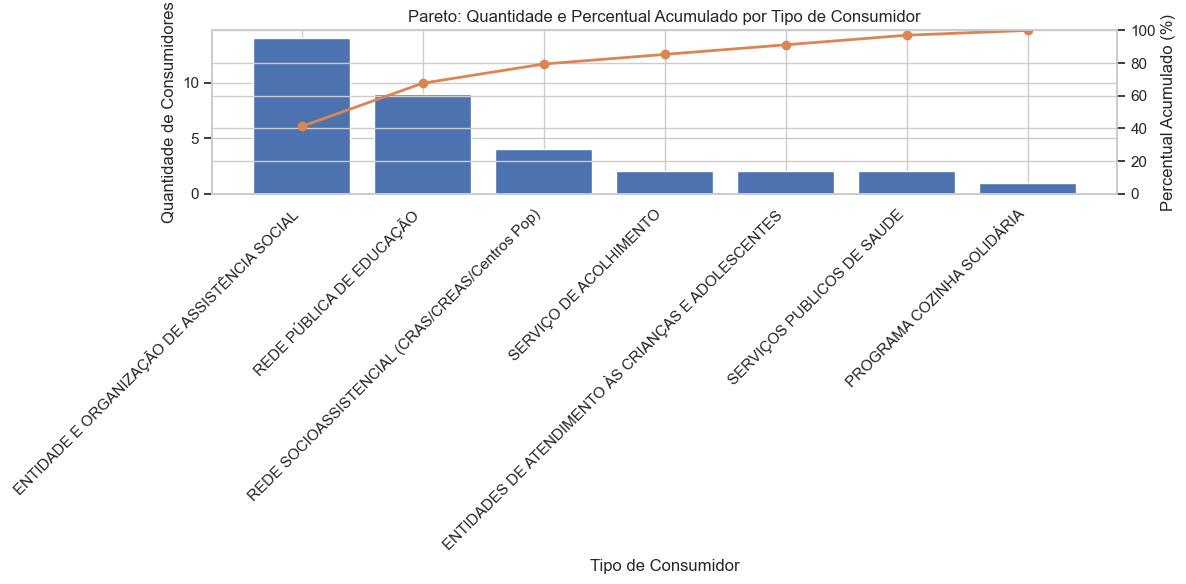

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

# Tabela com cumulativo
df_top = df_analise_percentual.copy().reset_index(drop=True)
df_top['Cumul Percent'] = df_top['Percentual Consumidor'].cumsum()

print("Tabela com cumulativo:")
display(df_top)

# Identificar categorias necessárias para alcançar 80% (Pareto)
threshold = 80.0
idx_80 = df_top['Cumul Percent'].searchsorted(threshold)
if idx_80 >= len(df_top):
    top80 = df_top
else:
    top80 = df_top.iloc[:idx_80+1]

print(f"\nCategorias que acumulam até {threshold}%:")
display(top80)

# Exportar tabela para CSV
out_path = Path.cwd() / 'TABELAS' / 'analise_percentual.csv'
df_top.to_csv(out_path, index=False)
print(f"\nTabela exportada para: {out_path}")

# Gráfico Pareto (barras de quantidade + linha acumulada percentual)
plt.figure(figsize=(12,6))
ax = plt.gca()

# Ordem decrescente já presente em df_top
x = range(len(df_top))
ax.bar(x, df_top['Qtd Consumidor'], color='C0')
ax.set_xticks(x)
ax.set_xticklabels(df_top['Tipo Consumidor'], rotation=45, ha='right')
ax.set_ylabel('Quantidade de Consumidores')
ax.set_xlabel('Tipo de Consumidor')

ax2 = ax.twinx()
ax2.plot(x, df_top['Cumul Percent'], color='C1', marker='o', linewidth=2)
ax2.set_ylabel('Percentual Acumulado (%)')
ax2.set_ylim(0, 100)

plt.title('Pareto: Quantidade e Percentual Acumulado por Tipo de Consumidor')
plt.tight_layout()
plt.show()

In [1]:
# Exibir as primeiras 5 linhas do DataFrame
print("\nPrimeiras 5 linhas do DataFrame:")
display(df.head())


Primeiras 5 linhas do DataFrame:


NameError: name 'df' is not defined

In [ ]:
# Exibir informações gerais sobre o DataFrame (tipos de dados, valores não nulos, etc.)
print("\nInformações do DataFrame:")
display(df.info())


Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Tipo Consumidor.Tipo Consumidor  7 non-null      object
 1   Qtd Consumidor                   7 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 244.0+ bytes


None

In [ ]:
# Exibir estatísticas descritivas para colunas numéricas
print("\nEstatísticas Descritivas:")
display(df.describe())


Estatísticas Descritivas:


,Qtd Consumidor
count,7.000000
mean,4.857143
std,5.047394
min,1.000000
25%,2.000000
50%,2.000000
75%,6.000000
max,15.000000


In [ ]:
# Verificar valores ausentes
print("\nValores ausentes por coluna:")
display(df.isnull().sum())


Valores ausentes por coluna:


,0
Tipo Consumidor.Tipo Consumidor,0
Qtd Consumidor,0


### 3. Preparação dos Dados e Geração de Novos Insights

Com base na análise inicial, vamos primeiro renomear a coluna para facilitar a manipulação. Em seguida, vamos gerar um novo dado calculando a participação percentual de cada tipo de consumidor na quantidade total. Isso nos dará uma nova perspectiva sobre a distribuição dos consumidores.

In [2]:
# Renomear a coluna 'Tipo Consumidor.Tipo Consumidor' para 'Tipo Consumidor'
df = df.rename(columns={'Tipo Consumidor.Tipo Consumidor': 'Tipo Consumidor'})
print("Coluna 'Tipo Consumidor.Tipo Consumidor' renomeada para 'Tipo Consumidor'.")

# Calcular a quantidade total de consumidores
total_consumidores = df['Qtd Consumidor'].sum()

# Calcular a participação percentual de cada tipo de consumidor
df['Percentual Consumidor'] = (df['Qtd Consumidor'] / total_consumidores) * 100

# Exibir o DataFrame atualizado com o novo dado
print("\nDataFrame com o novo dado 'Percentual Consumidor':")
display(df.head())

# Criar uma nova tabela/DataFrame com este novo dado
df_analise_percentual = df[['Tipo Consumidor', 'Qtd Consumidor', 'Percentual Consumidor']].sort_values(by='Percentual Consumidor', ascending=False)
print("\nNova Tabela de Análise Percentual (ordenada por percentual):")
display(df_analise_percentual)

Coluna 'Tipo Consumidor.Tipo Consumidor' renomeada para 'Tipo Consumidor'.

DataFrame com o novo dado 'Percentual Consumidor':


,Tipo Consumidor,Qtd Consumidor,Percentual Consumidor
0,ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL,14,41.176471
1,ENTIDADES DE ATENDIMENTO ÀS CRIANÇAS E ADOLESC...,2,5.882353
2,PROGRAMA COZINHA SOLIDÁRIA,1,2.941176
3,REDE PÚBLICA DE EDUCAÇÃO,9,26.470588
4,REDE SOCIOASSISTENCIAL (CRAS/CREAS/Centros Pop),4,11.764706



Nova Tabela de Análise Percentual (ordenada por percentual):


,Tipo Consumidor,Qtd Consumidor,Percentual Consumidor
0,ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL,14,41.176471
3,REDE PÚBLICA DE EDUCAÇÃO,9,26.470588
4,REDE SOCIOASSISTENCIAL (CRAS/CREAS/Centros Pop),4,11.764706
5,SERVIÇO DE ACOLHIMENTO,2,5.882353
1,ENTIDADES DE ATENDIMENTO ÀS CRIANÇAS E ADOLESC...,2,5.882353
6,SERVIÇOS PUBLICOS DE SAUDE,2,5.882353
2,PROGRAMA COZINHA SOLIDÁRIA,1,2.941176


### 4. Visualização dos Dados

Para apresentar o projeto na faculdade, uma visualização clara é essencial. Vamos criar um gráfico de barras para mostrar a distribuição da quantidade de consumidores por tipo, e também podemos visualizar os percentuais.

### 5. Análise Estatística Adicional

Vamos agora calcular algumas estatísticas adicionais para as colunas numéricas, como a quantidade e o percentual de consumidores, para entender melhor sua distribuição.

In [3]:
print("\nEstatísticas Descritivas para 'Qtd Consumidor':")
display(df_analise_percentual['Qtd Consumidor'].describe())

print("\nEstatísticas Descritivas para 'Percentual Consumidor':")
display(df_analise_percentual['Percentual Consumidor'].describe())


Estatísticas Descritivas para 'Qtd Consumidor':


count     7.000000
mean      4.857143
std       4.845223
min       1.000000
25%       2.000000
50%       2.000000
75%       6.500000
max      14.000000
Name: Qtd Consumidor, dtype: float64


Estatísticas Descritivas para 'Percentual Consumidor':


count     7.000000
mean     14.285714
std      14.250657
min       2.941176
25%       5.882353
50%       5.882353
75%      19.117647
max      41.176471
Name: Percentual Consumidor, dtype: float64

### Interpretação das Estatísticas Descritivas

As estatísticas descritivas calculadas para 'Qtd Consumidor' e 'Percentual Consumidor' revelam insights importantes sobre a distribuição dos dados:

*   **Variabilidade Considerável:** Tanto a quantidade quanto o percentual de consumidores apresentam um desvio padrão relativamente alto em comparação com suas médias (5.05 vs. 4.86 para quantidade e 14.85% vs. 14.29% para percentual). Isso indica que a distribuição entre os diferentes tipos de consumidores é bastante desigual, com alguns tipos atendendo a um número significativamente maior de consumidores do que outros.

*   **Assimetria (Skewness):** A mediana para 'Qtd Consumidor' (2) é consideravelmente menor que a média (4.86), e o mesmo ocorre com 'Percentual Consumidor' (mediana de 5.88% vs. média de 14.29%). Isso sugere uma distribuição assimétrica positiva, onde a maioria dos tipos de consumidores se concentra em valores mais baixos, enquanto alguns poucos tipos possuem valores muito mais altos, 'puxando' a média para cima.

*   **Disparidade entre Mínimo e Máximo:** A diferença entre os valores mínimos (1 consumidor, 2.94% de participação) e máximos (15 consumidores, 44.12% de participação) reforça a ideia de que há tipos de consumidores com grande representatividade e outros com participação mais modesta no programa.

Em resumo, essa análise estatística quantifica o que já era visível nos gráficos: o Programa de Aquisição de Alimentos atende a uma gama variada de tipos de consumidores, mas com uma concentração de esforços ou demanda em poucos grupos, enquanto a maioria tem uma participação menor.

### Resumo do Impacto para o PAA 2025

Com base nas análises realizadas, é possível observar que o Programa de Aquisição de Alimentos (PAA) para 2025 demonstra uma distribuição heterogênea de seus beneficiários. Há uma clara concentração de consumidores em alguns tipos de entidades, como as 'ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL' e a 'REDE PÚBLICA DE EDUCAÇÃO', que juntas respondem por uma parcela significativa dos atendimentos.

Essa concentração pode indicar:

*   **Eficiência na Distribuição:** O programa pode estar alcançando grandes volumes de consumidores através de parcerias estratégicas com instituições maiores e com maior capacidade de alcance.
*   **Necessidades Concentradas:** Pode refletir uma demanda maior em certos setores ou grupos de consumidores que essas entidades representam.
*   **Oportunidades de Otimização:** Ao mesmo tempo, a assimetria na distribuição sugere que há espaço para investigar as razões pelas quais outros tipos de consumidores têm uma participação menor. Isso pode levar a estratégias para fortalecer o alcance do programa em grupos com menor representatividade, garantindo uma cobertura mais equitativa e maximizando o impacto social do PAA em 2025. A compreensão dessas disparidades é crucial para o planejamento e a alocação de recursos futuros, visando atender de forma mais abrangente às diversas necessidades da população.

Matplotlib is building the font cache; this may take a moment.
C:\Users\Pedro Bugs\AppData\Local\Temp\ipykernel_1108\347737531.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Qtd Consumidor', y='Tipo Consumidor', data=df_analise_percentual, palette='viridis')


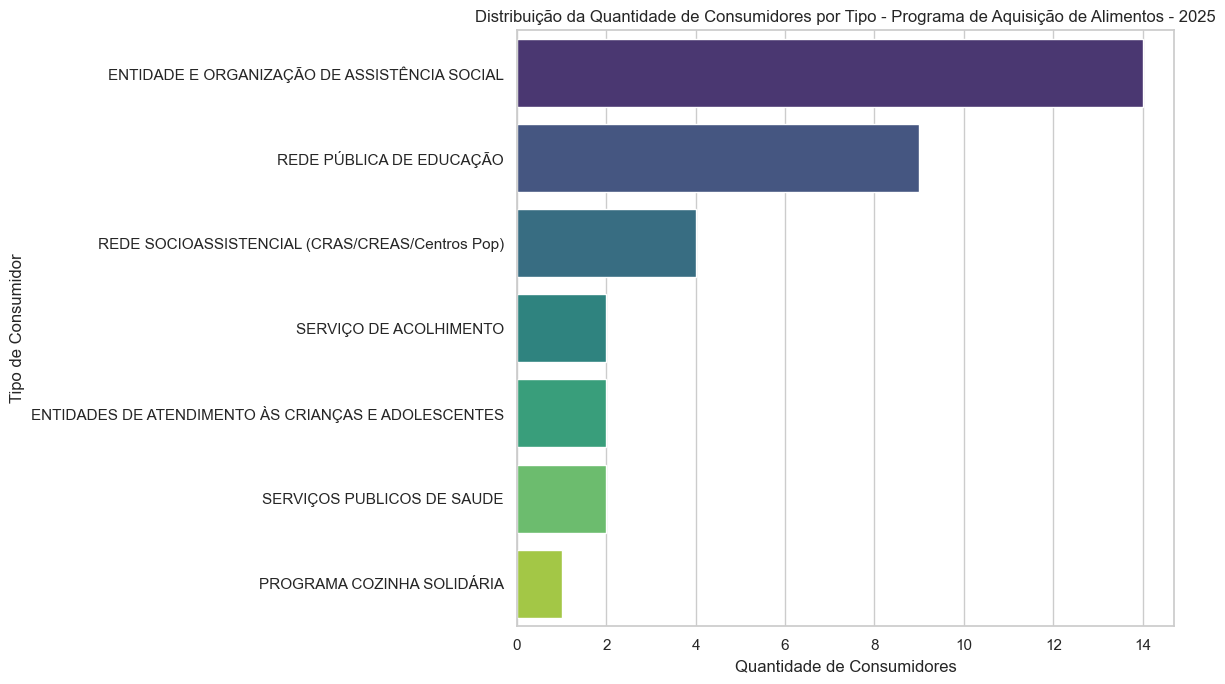

C:\Users\Pedro Bugs\AppData\Local\Temp\ipykernel_1108\347737531.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Percentual Consumidor', y='Tipo Consumidor', data=df_analise_percentual, palette='magma')


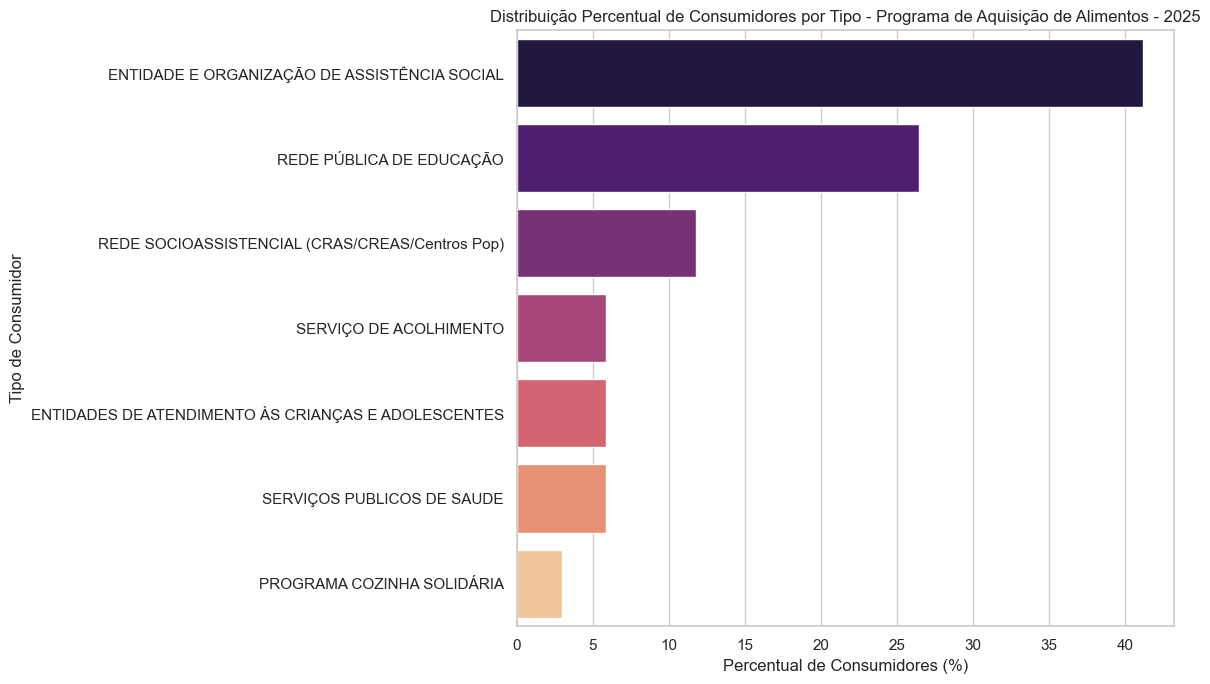

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))
sns.barplot(x='Qtd Consumidor', y='Tipo Consumidor', data=df_analise_percentual, palette='viridis')
plt.title('Distribuição da Quantidade de Consumidores por Tipo - Programa de Aquisição de Alimentos - 2025')
plt.xlabel('Quantidade de Consumidores')
plt.ylabel('Tipo de Consumidor')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Percentual Consumidor', y='Tipo Consumidor', data=df_analise_percentual, palette='magma')
plt.title('Distribuição Percentual de Consumidores por Tipo - Programa de Aquisição de Alimentos - 2025')
plt.xlabel('Percentual de Consumidores (%)')
plt.ylabel('Tipo de Consumidor')
plt.tight_layout()
plt.show()

### Comparação entre 'Quantidade de Consumidores' e 'Percentual de Consumidores'

Ao analisarmos os dados, trabalhamos inicialmente com a **'Quantidade de Consumidores'** (`Qtd Consumidor`), que representa o número absoluto de consumidores atendidos por cada 'Tipo Consumidor'. Essa métrica é fundamental para entender o volume bruto de atendimento de cada categoria.

No entanto, para termos uma visão mais contextualizada e comparável, geramos a coluna **'Percentual Consumidor'**. Esta coluna expressa a participação de cada 'Tipo Consumidor' em relação ao *total geral* de consumidores. As principais diferenças e benefícios dessa nova métrica são:

1.  **Contextualização:** A quantidade absoluta pode ser enganosa. Um tipo de consumidor com 10 atendimentos pode parecer pouco, mas se o total geral for 20, ele representa 50% dos atendimentos, o que é um dado muito relevante. O percentual coloca o número em perspectiva.

2.  **Comparabilidade:** Facilita a comparação entre diferentes tipos de consumidores, independentemente da escala. Por exemplo, dizer que 'ENTIDADE E ORGANIZAÇÃO DE ASSISTÊNCIA SOCIAL' tem 15 consumidores e 'PROGRAMA COZINHA SOLIDÁRIA' tem 1 consumidor pode não ser tão impactante quanto dizer que representam 44.12% e 2.94% do total, respectivamente. O percentual padroniza a base de comparação.

3.  **Identificação de Relevância:** O percentual ajuda a identificar rapidamente quais tipos de consumidores são os maiores beneficiários ou têm o maior peso no programa. Isso é crucial para a alocação de recursos e para entender onde o programa está tendo o maior impacto ou onde há maior demanda.

4.  **Análise de Distribuição:** Juntamente com as estatísticas descritivas, o percentual nos permite observar a assimetria na distribuição (como visto na análise estatística anterior). Ele reforça a ideia de que poucos tipos de consumidores concentram uma grande parte dos atendimentos, enquanto a maioria tem uma participação menor.

Em resumo, enquanto a 'Quantidade de Consumidores' nos dá o 'quê' (o número de atendimentos), o 'Percentual Consumidor' nos dá o 'quão significativo' (a proporção desses atendimentos no contexto geral), sendo ambos complementares para uma análise completa e para embasar decisões estratégicas.

### 6. Exportar o Notebook para HTML para Apresentação

Para facilitar a apresentação em um site, podemos exportar todo o conteúdo deste notebook para um arquivo HTML. Isso permitirá que você tenha uma versão estática e interativa (para gráficos, por exemplo) do seu trabalho para compartilhar.

In [1]:
import subprocess
import sys

# Instala o nbconvert de forma compatível com Windows e VS Code.
subprocess.check_call([sys.executable, "-m", "pip", "install", "nbconvert"])
print("nbconvert instalado com sucesso!")

nbconvert instalado com sucesso!


In [2]:
from pathlib import Path
import subprocess
import sys

# Usa o nome do notebook aberto no VS Code ou permite definir manualmente.
notebook_path = Path(r"c:\Big data Python\Untitled2.ipynb")

if not notebook_path.exists():
    raise FileNotFoundError(f"Notebook não encontrado: {notebook_path}")

output_html_filename = notebook_path.with_suffix(".html")

# Garante que o nbconvert exista antes da exportação.
subprocess.check_call([sys.executable, "-m", "pip", "install", "nbconvert"])

print(f"Gerando {output_html_filename.name}...")
subprocess.check_call([
    sys.executable,
    "-m",
    "jupyter",
    "nbconvert",
    "--to",
    "html",
    str(notebook_path),
])
print(f"\nNotebook exportado para '{output_html_filename}' no diretório atual.")

Gerando Untitled2.html...

Notebook exportado para 'c:\Big data Python\Untitled2.html' no diretório atual.


### Como usar o arquivo HTML para seu site:

1.  **Baixe o arquivo HTML:** Após a execução do código acima, o arquivo HTML (por exemplo, `Meu_Trabalho_PAA.html`) será gerado. Você pode encontrá-lo no painel de arquivos do Colab (ícone de pasta à esquerda) na pasta `/content/`. Clique com o botão direito no arquivo e selecione 'Fazer download'.
2.  **Hospede seu site:** Você pode hospedar este arquivo HTML em diversas plataformas de hospedagem de sites estáticos (como GitHub Pages, Netlify, Vercel, ou até mesmo um servidor web simples). Basta fazer o upload do arquivo HTML para a plataforma escolhida.
3.  **Compartilhe o link:** Uma vez hospedado, você terá um link público para o seu site que pode ser compartilhado com qualquer pessoa!